In [159]:
import torch
import sys
import numba as nb
print(sys.path)
#sys.path.append('//Users/milliema/Documents/Year5/masterProject/toyBloch')
import sequence
#sys.path.append('//Users/milliema/Documents/Year5/masterProject/toyBloch/examples')


import numpy as np
import matplotlib.pyplot as plt
from simulate.kernels import cpu_non_selective, cpu_relaxation

['/Users/milliema/miniconda3/envs/bloch_envx/lib/python312.zip', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12/lib-dynload', '', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12/site-packages', '//Users/milliema/Documents/Year5/masterProject/toyBloch/examples', '//Users/milliema/Documents/Year5/masterProject/toyBloch']


## Relative Metrics

In [419]:
# Myelin
t1_myelin = 0.226
t2_myelin = 300 * 1e-6

# White matter
t1_wm = 0.9
t2_wm = 0.08

## 1. Inversion Recovery

In [ ]:
# Time step
dt = 2 # 10us


#df = np.array([0.0])
df = np.linspace( -500, 500, 200)

non_selective_dt = dt*1e-6



initial_magnetisation = np.array([0.0, 0.0, 1.0])
pulse = sequence.rf.hyperbolic_secant(1500, mu=5, bandwidth=2400, dt=dt)

optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude
rf = pulse.waveform
rf = rf.detach().cpu().numpy().astype(np.complex128)


# white matter
magnetisation_wm_rf = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf, initial_magnetisation)

print(magnetisation_wm_rf.shape)

# myelin
magnetisation_myelin_rf = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_magnetisation)
print(magnetisation_myelin_rf.shape)

NameError: name 'np' is not defined

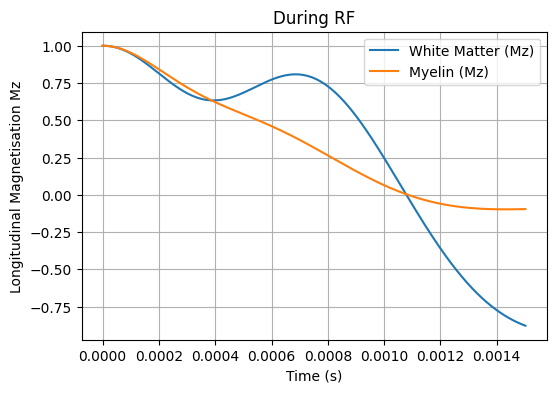

In [432]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf[0, :, 2], label='White Matter (Mz)')
plt.plot(time, magnetisation_myelin_rf[0, :, 2], label='Myelin (Mz)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('During RF')
plt.grid(True)
plt.legend()
plt.show()


In [433]:
# Time step
dt = 10 # 10us


#df = np.array([0.0])
df = np.linspace(-500, 5, 500)

non_selective_dt = dt*1e-6
zero_padding = int(4.5/non_selective_dt)


initial_magnetisation = np.array([0.0, 0.0, 1.0])
pulse = sequence.rf.hyperbolic_secant(1500, mu=5, bandwidth=2400, dt=dt)

optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude
rf = pulse.waveform
rf = rf.detach().cpu().numpy().astype(np.complex128)
rf = np.pad(rf, (0, zero_padding))


print(rf)

print(zero_padding)
# white matter
magnetisation_wm_rf = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf, initial_magnetisation)

print(magnetisation_wm_rf.shape)

# myelin
magnetisation_myelin_rf = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_magnetisation)
print(magnetisation_myelin_rf.shape)


[1.16647680e-05+7.14477949e-07j 1.17421623e-05+1.43916589e-06j
 1.17757390e-05+2.17123193e-06j ... 0.00000000e+00+0.00000000e+00j
 0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
450000
(500, 450152, 3)
(500, 450152, 3)


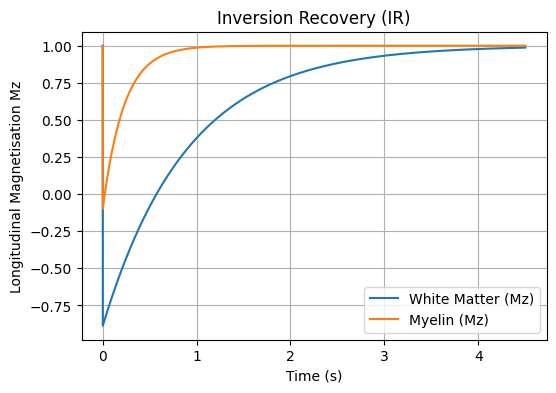

In [434]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf[0, :, 2], label='White Matter (Mz)')
plt.plot(time, magnetisation_myelin_rf[0, :, 2], label='Myelin (Mz)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend()
plt.show()




In [395]:
array_wm = magnetisation_wm_rf[0, :, 2]
print(array_wm)
idx = np.where(np.isclose(array_wm, 0, atol=1e-4))[0]
print(idx)


[1.         0.99951098 0.99802467 ... 0.98728777 0.98728791 0.98728805]
[57273 57274 57275 57276 57277 57278 57279 57280 57281 57282 57283 57284
 57285 57286 57287 57288 57289 57290]


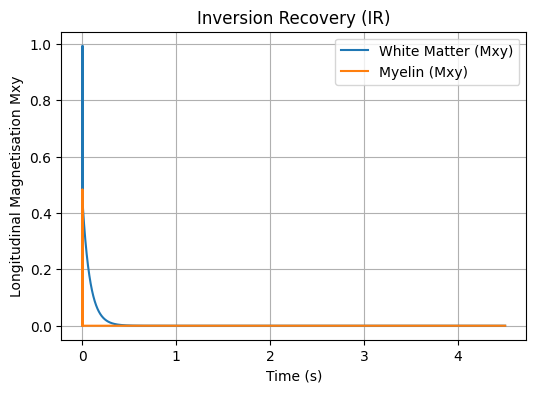

In [424]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
magnetisation_wm_xy = np.sqrt(np.power(magnetisation_wm_rf[0, :, 0], 2) + np.power(magnetisation_wm_rf[0, :, 1], 2))
magnetisation_myelin_xy = np.sqrt(np.power(magnetisation_myelin_rf[0, :, 0], 2) + np.power(magnetisation_myelin_rf[0, :, 1], 2))


plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_xy, label='White Matter (Mxy)')
plt.plot(time, magnetisation_myelin_xy, label='Myelin (Mxy)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mxy')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend()
plt.show()


In [300]:


# white matter
#magnetisation_wm_rf_final = magnetisation_wm_rf[:, index_extract+1, :][0,:]
#print(magnetisation_wm_rf_final)
magnetisation_wm_ir = cpu_relaxation(t1_wm, t2_wm, non_selective_dt, df, magnetisation_wm_rf[:, -1, :][0,:])
print(magnetisation_wm_ir.shape)

# myelin
# magnetisation_myelin_rf_final = magnetisation_myelin_rf[:, index_extract+1, :][0,:]
# print(magnetisation_myelin_rf_final)
magnetisation_myelin_ir = cpu_relaxation(t1_myelin, t2_myelin, non_selective_dt, df, magnetisation_wm_rf[:, -1, :][0,:])

(500, 450001, 3)


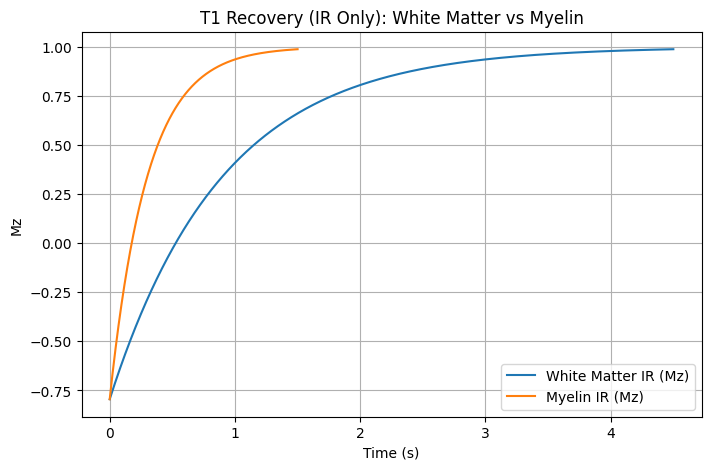

In [301]:
import matplotlib.pyplot as plt
import numpy as np

# Time axes for each IR signal
time_wm_ir = np.arange(magnetisation_wm_ir.shape[1]) * non_selective_dt
time_myelin_ir = np.arange(magnetisation_myelin_ir.shape[1]) * non_selective_dt

plt.figure(figsize=(8, 5))

# White matter IR
plt.plot(time_wm_ir,
         magnetisation_wm_ir[0, :, 2],
         label='White Matter IR (Mz)')

# Myelin IR
plt.plot(time_myelin_ir,
         magnetisation_myelin_ir[0, :, 2],
         label='Myelin IR (Mz)')

plt.xlabel("Time (s)")
plt.ylabel("Mz")
plt.title("T1 Recovery (IR Only): White Matter vs Myelin")
plt.grid(True)
plt.legend()
plt.show()
